# Exploring The Guardian's University League Tables
The following code explore the overall ranking and the individual subject-level rankings using data visualizations, correlation metrics, and basic statistical analysis.

## Load Tables
The following code loads the overall table as well as individual tables for each subject area.

In [2]:
from extract_data import load_data

ranking = load_data()

main_rank = ranking["main_rank"]
subjects = ranking["subjects"]
subject_dataframes = ranking["subject_dataframes"]

In [11]:
# Preview main table
main_rank.head(3)

,institutionId,name,url,rank2026,rank2025,rank2024,guardianScore,percentSatisfiedWithTeaching,expenditurePerStudent,studentStaffRatio,careerProspects,valueAdded,averageEntryTariff,percentSatisfiedWithAssessment,continuation
0,0156,Oxford,https://www.theguardian.com/education/2009/may...,1,1.0,2.0,100,94,10,9.1,92,6.3,197,76,97.3
1,0173,St Andrews,https://www.theguardian.com/education/2009/may...,2,2.0,1.0,98.4,92.8,6.5,11,90,5.5,210,81.7,96.8
2,0114,Cambridge,https://www.theguardian.com/education/2009/may...,3,3.0,3.0,94.6,93.4,9.4,10.8,92,5.9,210,72.9,98.4


### Save files
To avoid having to reload ranking data, save to files.

In [5]:
from pathlib import Path
import pickle

data_dir = Path("data")
data_dir.mkdir(exist_ok=True, parents=True)

output_path = data_dir / "main_rank.csv"
main_rank.to_csv(output_path, index=False)

with open(data_dir / "data.pkl", "wb") as f:
    pickle.dump(subject_dataframes, f)

## Data Exploration
First select only subjects for which Anglia Ruskin is a provider.

In [ ]:
subject_dataframes_anglia = {
    subject_id: subject_df
    for subject_id, subject_df in subject_dataframes.items()
    if subject_df["name"].eq("Anglia Ruskin").any()
}

37

In [35]:
metrics

['percentSatisfiedWithTeaching',
 'expenditurePerStudent',
 'studentStaffRatio',
 'careerProspects',
 'valueAdded',
 'averageEntryTariff',
 'percentSatisfiedWithAssessment',
 'continuation']

### Plot Correlations
Plot correlations between main score and each metric.

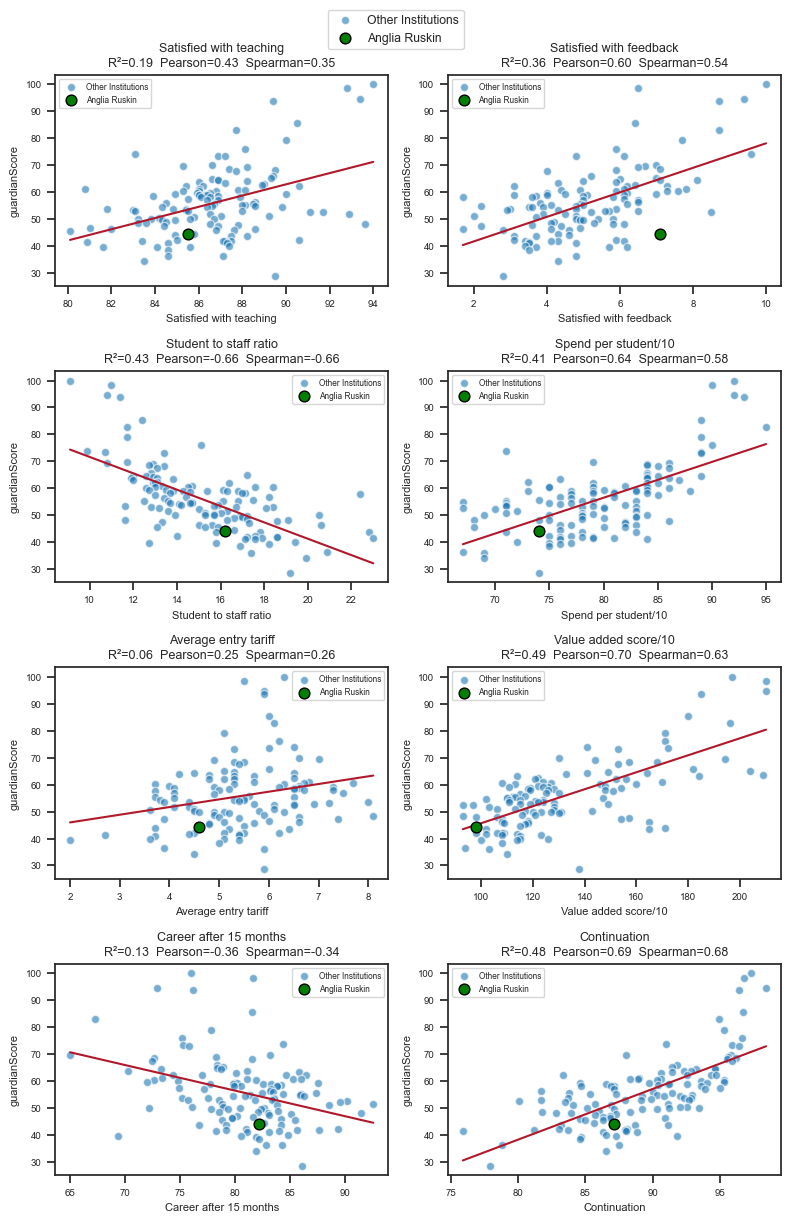

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
df = pd.read_csv("data/main_rank.csv")
TARGET = "guardianScore"
HIGHLIGHT = "Anglia Ruskin"

metrics = main_rank.columns[7:].to_list()

metrics_labels = ["Satisfied with teaching",
                  "Spend per student/10",
                  "Student to staff ratio",
                  "Career after 15 months",
                  "Value added score/10",
                  "Average entry tariff", 
                  "Satisfied with feedback",                 
                  "Continuation"]

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(8, 12))

for ax, col, label in zip(axes.flat, metrics, metrics_labels):
    sub = df[[col, TARGET, "name"]].dropna()
    x, y = sub[col].values, sub[TARGET].values

    # Fit linear regression
    slope, intercept, r_pearson, p_val, se = stats.linregress(x, y)
    r2 = r_pearson ** 2
    r_spearman, _ = stats.spearmanr(x, y)

    # Split highlighted institution from the rest
    is_highlight = sub["name"] == HIGHLIGHT
    rest, hl = sub[~is_highlight], sub[is_highlight]

    # Scatter: rest in blue, highlight in green (on top, larger, outlined)
    ax.scatter(rest[col], rest[TARGET], alpha=0.6, edgecolor="white", s=35, color="tab:blue",
               label="Other Institutions")
    ax.scatter(hl[col], hl[TARGET], color="green", edgecolor="black",
               s=60, zorder=5, label=HIGHLIGHT)

    # Regression line
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="#b2182b", linewidth=1.5)

    # Annotate stats
    ax.set_title(
        f"{label}\nR²={r2:.2f}  Pearson={r_pearson:.2f}  Spearman={r_spearman:.2f}",
        fontsize=9
    )
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc="best")

# Single shared legend for the highlighted institution
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()